# MERGE YOUTUBE DAN E-COMMERS

In [103]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

Saving dataset_ecommers_gadget.csv to dataset_ecommers_gadget (3).csv


## E-COMMERCE

In [104]:
ecommerce = pd.read_csv('dataset_ecommers_gadget.csv')
sentiment = pd.read_csv('dataset sentiment_final.csv')

In [105]:
ecommerce.head()

,brand,price,lokasi,rating,terjual,ecommerce
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,"Rp 21,390,000",Surabaya,4.9,568,Shopee
1,devilmimi realme series C71 4GB+8GB / 128 GB b...,"Rp 17,920,000",Surabaya,5.0,225,Shopee
2,[BARU] OPPO A6t Online Exclusive 4+64/128GB & ...,"Rp 19,990,000",Tangerang,4.9,"3,000",Shopee
3,Samsung Galaxy A07 4/64GB - Black,"Rp 15,990,000",Surabaya,4.9,"10,000",Shopee
4,itel City200 NFC RAM 128+8GB(4+4GB) - Big Batt...,"Rp 15,480,000",Jakarta Barat,4.9,"1,000",Shopee


In [106]:
ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6115 entries, 0 to 6114
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   brand      6115 non-null   object 
 1   price      6115 non-null   object 
 2   lokasi     6115 non-null   object 
 3   rating     6115 non-null   float64
 4   terjual    6115 non-null   object 
 5   ecommerce  6115 non-null   object 
dtypes: float64(1), object(5)
memory usage: 286.8+ KB


In [107]:
ecommerce.isnull().sum()

,0
brand,0
price,0
lokasi,0
rating,0
terjual,0
ecommerce,0


In [108]:
ecom = ecommerce.copy()
yt = sentiment.copy()

In [109]:
ecom.columns = ecom.columns.str.strip().str.lower()
print(ecom.columns)

Index(['brand', 'price', 'lokasi', 'rating', 'terjual', 'ecommerce'], dtype='object')


In [110]:
ecom['brand'] = ecom['brand'].astype(str).str.lower().str.strip()
ecom['brand'] = ecom['brand'].str.replace(r'\s+', ' ', regex=True)

In [111]:
def extract_brand(text):
    text = str(text).lower()

    if 'samsung' in text:
        return 'Samsung'
    elif 'iphone' in text or 'apple' in text:
        return 'Apple'
    elif 'xiaomi' in text:
        return 'Xiaomi'
    elif 'poco' in text:
        return 'POCO'
    elif 'realme' in text:
        return 'realme'
    elif 'oppo' in text:
        return 'OPPO'
    elif 'vivo' in text:
        return 'vivo'
    elif 'infinix' in text:
        return 'Infinix'
    elif 'tecno' in text:
        return 'TECNO'
    elif 'itel' in text:
        return 'itel'
    elif 'iqoo' in text:
        return 'iQOO'
    elif 'asus' in text:
        return 'ASUS'
    elif 'redmi' in text:
        return 'Xiaomi'
    else:
        return 'Unknown'

In [112]:
ecom['brand_clean'] = ecom['brand'].apply(extract_brand)

print(ecom[['brand', 'brand_clean']].head(10))
print(ecom['brand_clean'].value_counts())

                                               brand brand_clean
0  devilmimi realme c71 8gb+16gb / 128gb handphon...      realme
1  devilmimi realme series c71 4gb+8gb / 128 gb b...      realme
2  [baru] oppo a6t online exclusive 4+64/128gb & ...        OPPO
3                  samsung galaxy a07 4/64gb - black     Samsung
4  itel city200 nfc ram 128+8gb(4+4gb) - big batt...        itel
5  xiaomi redmi note 15 (6/128 gb) (8/128 gb) (8/...      Xiaomi
6                 samsung galaxy a16 8/128gb - black     Samsung
7  oppo reno13 f 4g 8gb/256gb [ip69 water resista...        OPPO
8  poco c85 (6/128 gb) (8/256 gb) baterai besar 6...        POCO
9  xiaomi redmi 15 (8gb/128gb) (8gb/256gb) batera...      Xiaomi
brand_clean
Unknown    1202
Samsung     976
Xiaomi      785
Infinix     671
OPPO        554
realme      542
TECNO       434
vivo        427
POCO        171
Apple       162
itel        154
ASUS         22
iQOO         15
Name: count, dtype: int64


In [113]:
def clean_price(value):
    value = str(value).lower()
    value = value.replace('rp', '')
    value = re.sub(r'[^0-9]', '', value)
    return pd.to_numeric(value, errors='coerce')

ecom['price_clean'] = ecom['price'].apply(clean_price)

In [114]:
def clean_rating(value):
    value = str(value).replace(',', '.')
    value = re.sub(r'[^0-9\.]', '', value)
    return pd.to_numeric(value, errors='coerce')

ecom['rating_clean'] = ecom['rating'].apply(clean_rating)

In [115]:
def clean_sold(value):
    value = str(value).lower().strip()

    if 'rb' in value:
        num = re.sub(r'[^0-9,\.]', '', value).replace(',', '.')
        try:
            return float(num) * 1000
        except:
            return np.nan

    elif 'jt' in value:
        num = re.sub(r'[^0-9,\.]', '', value).replace(',', '.')
        try:
            return float(num) * 1000000
        except:
            return np.nan

    else:
        value = re.sub(r'[^0-9]', '', value)
        return pd.to_numeric(value, errors='coerce')

ecom['terjual_clean'] = ecom['terjual'].apply(clean_sold)

In [116]:
ecom_clean = ecom.copy()

ecom_clean = ecom_clean[
    (ecom_clean['brand_clean'] != 'Unknown') &
    (ecom_clean['price_clean'].notna()) &
    (ecom_clean['rating_clean'].notna()) &
    (ecom_clean['terjual_clean'].notna())
]

ecom_clean = ecom_clean.drop_duplicates()

print(ecom_clean.shape)
print(ecom_clean[['brand_clean', 'price_clean', 'rating_clean', 'terjual_clean']].head())

(4672, 10)
  brand_clean  price_clean  rating_clean  terjual_clean
0      realme     21390000           4.9            568
1      realme     17920000           5.0            225
2        OPPO     19990000           4.9           3000
3     Samsung     15990000           4.9          10000
4        itel     15480000           4.9           1000


In [117]:
ecom_clean.to_csv('ecommerce_clean.csv', index=False)
print("File ecommerce_clean.csv berhasil disimpan")

File ecommerce_clean.csv berhasil disimpan


## YOUTUBE

In [118]:
sentiment.head()

,channel,username,text,tanggal,panjang_komentar,sentiment
0,Jagat Review,@CheverrlynAdyba,untuk link pembelian chamon pro g kok gk ada bang,2026-03-21 13:04:52+00:00,49,netral
1,Jagat Review,@caesarrizkie9742,ngomongin rog kah kameranya makin menurun soal...,2026-03-17 20:41:02+00:00,145,positif
2,Jagat Review,@adealfian664,sebagai user samsung one ui itu ui paling enak...,2026-03-13 23:27:54+00:00,633,netral
3,Jagat Review,@RsyatLyioz,tecno pova ultra g bg,2026-03-12 20:11:30+00:00,21,netral
4,Jagat Review,@CitraUtut,bang tolong buatin dong rekomendasi buat lebaran,2026-03-02 23:12:23+00:00,48,netral


In [119]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7632 entries, 0 to 7631
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   channel           7632 non-null   object
 1   username          7632 non-null   object
 2   text              7585 non-null   object
 3   tanggal           7632 non-null   object
 4   panjang_komentar  7632 non-null   int64 
 5   sentiment         7632 non-null   object
dtypes: int64(1), object(5)
memory usage: 357.9+ KB


In [120]:
yt.columns = yt.columns.str.strip().str.lower()
print(yt.columns)

Index(['channel', 'username', 'text', 'tanggal', 'panjang_komentar',
       'sentiment'],
      dtype='object')


In [121]:
yt['text'] = yt['text'].astype(str).str.lower().str.strip()
yt['text'] = yt['text'].str.replace(r'\s+', ' ', regex=True)

In [122]:
sentiment.isnull().sum()

,0
channel,0
username,0
text,47
tanggal,0
panjang_komentar,0
sentiment,0


In [123]:
# hapus missing value pada kolom text
yt = yt.dropna(subset=['text']).copy()

# bersihkan teks
yt['text'] = yt['text'].astype(str).str.lower().str.strip()
yt['text'] = yt['text'].str.replace(r'\s+', ' ', regex=True)

# hapus teks kosong
yt = yt[yt['text'] != ''].copy()

# reset index
yt = yt.reset_index(drop=True)

# cek hasil
print(yt.isnull().sum())
print("Jumlah data setelah dibersihkan:", yt.shape)

channel             0
username            0
text                0
tanggal             0
panjang_komentar    0
sentiment           0
dtype: int64
Jumlah data setelah dibersihkan: (7632, 6)


In [124]:
yt_clean = yt.copy()

yt_clean = yt_clean[yt_clean['text'].notna()]
yt_clean = yt_clean[yt_clean['text'].str.strip() != '']
yt_clean = yt_clean.drop_duplicates(subset=['text'])

print(yt_clean.shape)

(7411, 6)


In [125]:
yt_clean['sentiment'] = yt_clean['sentiment'].astype(str).str.lower().str.strip()

yt_clean['sentiment'] = yt_clean['sentiment'].replace({
    'positive': 'positif',
    'negative': 'negatif',
    'neutral': 'netral',
    'positif ': 'positif',
    'negatif ': 'negatif',
    'netral ': 'netral'
})

print(yt_clean['sentiment'].value_counts())

sentiment
netral     6320
positif     963
negatif     128
Name: count, dtype: int64


In [126]:
def extract_brand_from_comment(text):
    text = str(text).lower()

    found_brands = []

    if 'samsung' in text:
        found_brands.append('Samsung')
    if 'iphone' in text or 'apple' in text:
        found_brands.append('Apple')
    if 'xiaomi' in text or 'redmi' in text:
        found_brands.append('Xiaomi')
    if 'poco' in text:
        found_brands.append('POCO')
    if 'realme' in text:
        found_brands.append('realme')
    if 'oppo' in text:
        found_brands.append('OPPO')
    if 'vivo' in text:
        found_brands.append('vivo')
    if 'infinix' in text:
        found_brands.append('Infinix')
    if 'tecno' in text:
        found_brands.append('TECNO')
    if 'itel' in text:
        found_brands.append('itel')
    if 'iqoo' in text:
        found_brands.append('iQOO')
    if 'asus' in text:
        found_brands.append('ASUS')

    if len(found_brands) == 1:
        return found_brands[0]
    elif len(found_brands) > 1:
        return 'Multi-brand'
    else:
        return 'Unknown'

In [127]:
yt_clean['brand_clean'] = yt_clean['text'].apply(extract_brand_from_comment)
yt_clean['brand_clean'].value_counts()

,count
brand_clean,
Unknown,4602
POCO,508
Infinix,422
Multi-brand,388
Xiaomi,302
Samsung,298
TECNO,174
OPPO,155
vivo,145


In [128]:
yt_clean[['text', 'brand_clean']].head(10)

,text,brand_clean
0,untuk link pembelian chamon pro g kok gk ada bang,Unknown
1,ngomongin rog kah kameranya makin menurun soal...,Unknown
2,sebagai user samsung one ui itu ui paling enak...,Samsung
3,tecno pova ultra g bg,TECNO
4,bang tolong buatin dong rekomendasi buat lebaran,Unknown
5,gue dapet infinix gt pro di harga juta baru ta...,Infinix
6,beli toko apa bg,Unknown
7,kalo samsung sfeg aman kh beli taun,Samsung
8,bingung gua di seri juta ini pada bagus bagus ...,Multi-brand
9,kalo camera mending camon tapi kalo untuk ke g...,Unknown


In [129]:
score_map = {
    'positif': 1,
    'netral': 0,
    'negatif': -1
}

yt_clean['sentiment_score'] = yt_clean['sentiment'].map(score_map)

In [130]:
yt_clean = yt_clean[
    (yt_clean['brand_clean'] != 'Unknown') &
    (yt_clean['brand_clean'] != 'Multi-brand') &
    (yt_clean['sentiment_score'].notna())
]

yt_clean.shape
yt_clean['brand_clean'].value_counts()

,count
brand_clean,
POCO,508
Infinix,422
Xiaomi,302
Samsung,298
TECNO,174
OPPO,155
vivo,145
realme,130
Apple,127


In [131]:
yt_clean.to_csv('sentiment_clean.csv', index=False)
print("File sentiment_clean.csv berhasil disimpan")

File sentiment_clean.csv berhasil disimpan


## SENTIMENT BRAND AGREGASI

In [132]:
sentiment_brand_agg = yt_clean.groupby('brand_clean').agg(
    total_komentar=('text', 'count'),
    jumlah_positif=('sentiment', lambda x: (x == 'positif').sum()),
    jumlah_netral=('sentiment', lambda x: (x == 'netral').sum()),
    jumlah_negatif=('sentiment', lambda x: (x == 'negatif').sum()),
    sentiment_score_avg=('sentiment_score', 'mean')
).reset_index()

In [133]:
sentiment_brand_agg['persen_positif'] = (
    sentiment_brand_agg['jumlah_positif'] / sentiment_brand_agg['total_komentar'] * 100
)

sentiment_brand_agg['persen_netral'] = (
    sentiment_brand_agg['jumlah_netral'] / sentiment_brand_agg['total_komentar'] * 100
)

sentiment_brand_agg['persen_negatif'] = (
    sentiment_brand_agg['jumlah_negatif'] / sentiment_brand_agg['total_komentar'] * 100
)

sentiment_brand_agg = sentiment_brand_agg.sort_values(by='sentiment_score_avg', ascending=False)

sentiment_brand_agg

,brand_clean,total_komentar,jumlah_positif,jumlah_netral,jumlah_negatif,sentiment_score_avg,persen_positif,persen_netral,persen_negatif
0,ASUS,19,5,13,1,0.210526,26.315789,68.421053,5.263158
8,iQOO,99,17,81,1,0.161616,17.171717,81.818182,1.010101
6,TECNO,174,29,142,3,0.149425,16.666667,81.609195,1.724138
1,Apple,127,20,105,2,0.141732,15.748031,82.677165,1.574803
11,vivo,145,21,122,2,0.131034,14.482759,84.137931,1.379310
7,Xiaomi,302,40,253,9,0.102649,13.245033,83.774834,2.980132
5,Samsung,298,39,249,10,0.097315,13.087248,83.557047,3.355705
2,Infinix,422,49,365,8,0.097156,11.611374,86.492891,1.895735
4,POCO,508,52,447,9,0.084646,10.236220,87.992126,1.771654
9,itel,42,6,33,3,0.071429,14.285714,78.571429,7.142857


Hasil analisis sentiment menunjukkan bahwa sebagian besar komentar bersifat netral, dengan persentase netral yang mendominasi di hampir semua brand.
Hal ini mengindikasikan bahwa pengguna cenderung memberikan komentar informatif atau biasa, bukan opini yang sangat positif maupun negatif.

Brand dengan sentiment tertinggi seperti ASUS, iQOO, dan TECNO menunjukkan bahwa meskipun jumlah komentarnya relatif sedikit,
respon pengguna terhadap brand tersebut cenderung lebih positif.

Sebaliknya, brand seperti OPPO, realme, dan itel memiliki nilai sentiment yang lebih rendah,
yang menunjukkan bahwa persepsi pengguna terhadap brand tersebut cenderung kurang kuat dibandingkan brand lainnya.

In [134]:
sentiment_brand_agg.to_csv('sentiment_brand_agg.csv', index=False)
print("File sentiment_brand_agg.csv berhasil disimpan")

File sentiment_brand_agg.csv berhasil disimpan


## E-COMMERCE BRAND AGREGASI

In [135]:
ecommerce_brand_agg = ecom_clean.groupby('brand_clean').agg(
    total_listing=('brand_clean', 'count'),
    total_terjual=('terjual_clean', 'sum'),
    avg_harga=('price_clean', 'mean'),
    avg_rating=('rating_clean', 'mean')
).reset_index()

ecommerce_brand_agg = ecommerce_brand_agg.sort_values(by='total_terjual', ascending=False)
ecommerce_brand_agg

,brand_clean,total_listing,total_terjual,avg_harga,avg_rating
7,Xiaomi,735,579681,2.830128e+07,44.932245
5,Samsung,930,389413,4.127120e+07,29.179462
2,Infinix,651,288713,1.851592e+07,81.365899
11,vivo,393,229482,2.902472e+07,119.126718
10,realme,527,119568,2.597612e+07,65.688615
4,POCO,165,88562,3.177481e+07,38.739394
3,OPPO,527,75635,3.122047e+07,24.542884
1,Apple,146,59109,8.275644e+07,18.062329
6,TECNO,414,46385,2.543627e+07,8.928261
9,itel,147,29878,1.442001e+07,15.795918


Hasil agregasi data e-commerce menunjukkan bahwa Xiaomi, Samsung, dan Infinix merupakan brand dengan jumlah penjualan tertinggi.
Hal ini menunjukkan bahwa brand dengan harga kompetitif dan segmentasi pasar yang luas cenderung lebih diminati oleh konsumen.

Sementara itu, brand seperti ASUS, iQOO, dan itel memiliki penjualan yang relatif rendah,
yang dapat disebabkan oleh segmentasi pasar yang lebih sempit, harga yang lebih tinggi, atau kurangnya distribusi dan promosi.

Secara umum, data ini menunjukkan bahwa faktor harga, ketersediaan produk, dan kekuatan brand memiliki pengaruh besar terhadap keputusan pembelian.

In [136]:
ecommerce_brand_agg.to_csv('ecommerce_brand_agg.csv', index=False)
print("File ecommerce_brand_agg.csv berhasil disimpan")

File ecommerce_brand_agg.csv berhasil disimpan


## FINAL BRAND

In [137]:
final_brand_comparison = pd.merge(
    sentiment_brand_agg,
    ecommerce_brand_agg,
    on='brand_clean',
    how='inner'
)

final_brand_comparison

,brand_clean,total_komentar,jumlah_positif,jumlah_netral,jumlah_negatif,sentiment_score_avg,persen_positif,persen_netral,persen_negatif,total_listing,total_terjual,avg_harga,avg_rating
0,ASUS,19,5,13,1,0.210526,26.315789,68.421053,5.263158,22,170,5.830798e+07,8.450000
1,iQOO,99,17,81,1,0.161616,17.171717,81.818182,1.010101,15,2100,4.588293e+07,4.920000
2,TECNO,174,29,142,3,0.149425,16.666667,81.609195,1.724138,414,46385,2.543627e+07,8.928261
3,Apple,127,20,105,2,0.141732,15.748031,82.677165,1.574803,146,59109,8.275644e+07,18.062329
4,vivo,145,21,122,2,0.131034,14.482759,84.137931,1.379310,393,229482,2.902472e+07,119.126718
5,Xiaomi,302,40,253,9,0.102649,13.245033,83.774834,2.980132,735,579681,2.830128e+07,44.932245
6,Samsung,298,39,249,10,0.097315,13.087248,83.557047,3.355705,930,389413,4.127120e+07,29.179462
7,Infinix,422,49,365,8,0.097156,11.611374,86.492891,1.895735,651,288713,1.851592e+07,81.365899
8,POCO,508,52,447,9,0.084646,10.236220,87.992126,1.771654,165,88562,3.177481e+07,38.739394
9,itel,42,6,33,3,0.071429,14.285714,78.571429,7.142857,147,29878,1.442001e+07,15.795918


Penggabungan data sentiment YouTube dan data penjualan e-commerce menghasilkan gambaran yang lebih komprehensif mengenai performa brand di pasar.

Data ini memungkinkan perbandingan antara persepsi publik (sentiment) dengan kondisi nyata di pasar (penjualan),
sehingga dapat digunakan untuk mengidentifikasi apakah opini pengguna sejalan dengan perilaku pembelian.

Hasil ini menjadi dasar utama untuk analisis lanjutan seperti korelasi dan gap analysis.

In [138]:
final_brand_comparison.to_csv('final_brand_comparison.csv', index=False)
print("File final_brand_comparison.csv berhasil disimpan")

File final_brand_comparison.csv berhasil disimpan


## TOP 3 (TERBAIK DAN TERENDAH)

### TOP 3 PENJUALAN

In [139]:
top3_sales = final_brand_comparison.sort_values(by='total_terjual', ascending=False).head(3)
bottom3_sales = final_brand_comparison.sort_values(by='total_terjual', ascending=True).head(3)

print("=== TOP 3 PENJUALAN ===")
top3_sales[['brand_clean', 'total_terjual', 'avg_harga', 'avg_rating']]

=== TOP 3 PENJUALAN ===


,brand_clean,total_terjual,avg_harga,avg_rating
5,Xiaomi,579681,2.830128e+07,44.932245
6,Samsung,389413,4.127120e+07,29.179462
7,Infinix,288713,1.851592e+07,81.365899


In [140]:
print("=== BOTTOM 3 SENTIMENT ===")
bottom3_sentiment[['brand_clean', 'sentiment_score_avg', 'persen_positif', 'persen_negatif']]

=== BOTTOM 3 SENTIMENT ===


,brand_clean,sentiment_score_avg,persen_positif,persen_negatif
11,OPPO,0.051613,7.741935,2.580645
10,realme,0.053846,10.000000,4.615385
9,itel,0.071429,14.285714,7.142857


Brand dengan penjualan tertinggi didominasi oleh Xiaomi, Samsung, dan Infinix,
yang menunjukkan bahwa brand tersebut memiliki daya tarik pasar yang kuat.

Namun, brand dengan sentiment tertinggi seperti ASUS dan iQOO tidak termasuk dalam brand dengan penjualan tertinggi.
Hal ini menunjukkan bahwa persepsi positif tidak selalu berbanding lurus dengan tingkat penjualan.

Sebaliknya, beberapa brand dengan sentiment yang relatif rendah tetap memiliki penjualan tinggi,
yang mengindikasikan adanya faktor lain seperti harga, promosi, dan loyalitas brand yang mempengaruhi keputusan pembelian.

### TOP 3 SENTIMENT

In [141]:
top3_sentiment = final_brand_comparison.sort_values(by='sentiment_score_avg', ascending=False).head(3)
bottom3_sentiment = final_brand_comparison.sort_values(by='sentiment_score_avg', ascending=True).head(3)

print("=== TOP 3 SENTIMENT ===")
top3_sentiment[['brand_clean', 'sentiment_score_avg', 'persen_positif', 'persen_negatif']]

=== TOP 3 SENTIMENT ===


,brand_clean,sentiment_score_avg,persen_positif,persen_negatif
0,ASUS,0.210526,26.315789,5.263158
1,iQOO,0.161616,17.171717,1.010101
2,TECNO,0.149425,16.666667,1.724138


In [142]:
print("=== BOTTOM 3 SENTIMENT ===")
bottom3_sentiment[['brand_clean', 'sentiment_score_avg', 'persen_positif', 'persen_negatif']]

=== BOTTOM 3 SENTIMENT ===


,brand_clean,sentiment_score_avg,persen_positif,persen_negatif
11,OPPO,0.051613,7.741935,2.580645
10,realme,0.053846,10.000000,4.615385
9,itel,0.071429,14.285714,7.142857


In [143]:
correlation = final_brand_comparison['sentiment_score_avg'].corr(final_brand_comparison['total_terjual'])

print("Nilai Korelasi Pearson antara sentiment dan penjualan:", correlation)

Nilai Korelasi Pearson antara sentiment dan penjualan: -0.25648347935286675


In [144]:
if correlation > 0.7:
    print("Interpretasi: Korelasi positif kuat")
elif correlation > 0.3:
    print("Interpretasi: Korelasi positif sedang")
elif correlation > 0:
    print("Interpretasi: Korelasi positif lemah")
elif correlation < -0.7:
    print("Interpretasi: Korelasi negatif kuat")
elif correlation < -0.3:
    print("Interpretasi: Korelasi negatif sedang")
elif correlation < 0:
    print("Interpretasi: Korelasi negatif lemah")
else:
    print("Interpretasi: Tidak ada korelasi")

Interpretasi: Korelasi negatif lemah


Nilai korelasi antara sentiment dan penjualan menunjukkan hubungan negatif lemah.
Hal ini berarti bahwa peningkatan sentiment positif tidak secara signifikan diikuti oleh peningkatan penjualan.

Dengan kata lain, persepsi publik di YouTube tidak selalu mencerminkan kondisi pasar yang sebenarnya.
Faktor lain seperti harga, strategi pemasaran, dan distribusi produk memiliki peran yang lebih dominan dalam mempengaruhi penjualan.

Temuan ini menunjukkan bahwa analisis sentiment saja tidak cukup untuk memprediksi performa pasar secara akurat

In [145]:
median_sentiment = final_brand_comparison['sentiment_score_avg'].median()
median_sales = final_brand_comparison['total_terjual'].median()

def classify_gap(row):
    if row['sentiment_score_avg'] >= median_sentiment and row['total_terjual'] >= median_sales:
        return 'Sentiment tinggi + Penjualan tinggi'
    elif row['sentiment_score_avg'] >= median_sentiment and row['total_terjual'] < median_sales:
        return 'Sentiment tinggi + Penjualan rendah'
    elif row['sentiment_score_avg'] < median_sentiment and row['total_terjual'] >= median_sales:
        return 'Sentiment rendah + Penjualan tinggi'
    else:
        return 'Sentiment rendah + Penjualan rendah'

final_brand_comparison['gap_category'] = final_brand_comparison.apply(classify_gap, axis=1)

final_brand_comparison[['brand_clean', 'sentiment_score_avg', 'total_terjual', 'gap_category']]

,brand_clean,sentiment_score_avg,total_terjual,gap_category
0,ASUS,0.210526,170,Sentiment tinggi + Penjualan rendah
1,iQOO,0.161616,2100,Sentiment tinggi + Penjualan rendah
2,TECNO,0.149425,46385,Sentiment tinggi + Penjualan rendah
3,Apple,0.141732,59109,Sentiment tinggi + Penjualan rendah
4,vivo,0.131034,229482,Sentiment tinggi + Penjualan tinggi
5,Xiaomi,0.102649,579681,Sentiment tinggi + Penjualan tinggi
6,Samsung,0.097315,389413,Sentiment rendah + Penjualan tinggi
7,Infinix,0.097156,288713,Sentiment rendah + Penjualan tinggi
8,POCO,0.084646,88562,Sentiment rendah + Penjualan tinggi
9,itel,0.071429,29878,Sentiment rendah + Penjualan rendah


Hasil gap analysis menunjukkan adanya beberapa pola menarik antara sentiment dan penjualan.Brand seperti Xiaomi dan vivo termasuk dalam kategori sentiment tinggi dan penjualan tinggi,
yang menunjukkan bahwa persepsi publik sejalan dengan performa pasar.

Sebaliknya, brand seperti ASUS, iQOO, dan Apple memiliki sentiment tinggi tetapi penjualan rendah, yang mengindikasikan bahwa meskipun disukai, terdapat faktor penghambat seperti harga atau distribusi.

Brand seperti Samsung, Infinix, dan POCO memiliki penjualan tinggi meskipun sentiment relatif lebih rendah,
yang menunjukkan bahwa faktor seperti harga terjangkau, promosi, dan kekuatan brand tetap mendorong pembelian. Sementara itu, brand seperti OPPO dan itel memiliki sentiment dan penjualan yang sama-sama rendah,
yang menunjukkan perlunya peningkatan strategi produk maupun pemasaran.

## VISUALISASI

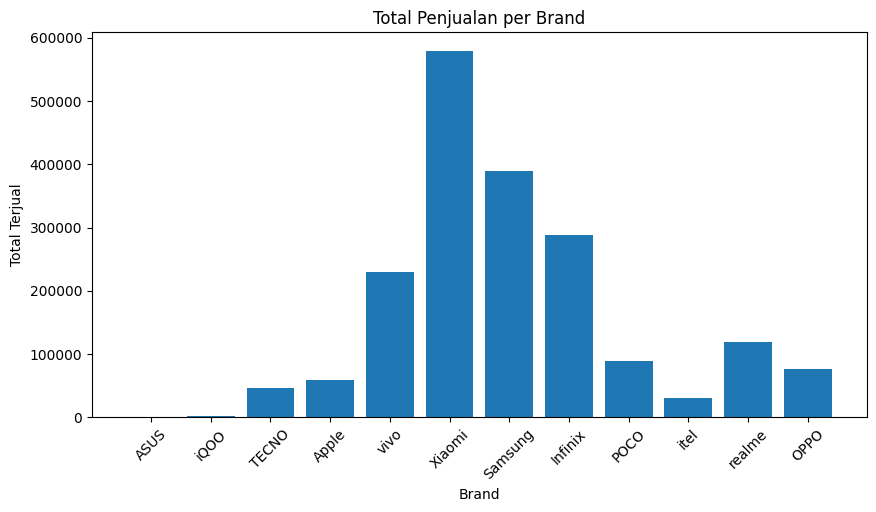

In [146]:
plt.figure(figsize=(10,5))
plt.bar(final_brand_comparison['brand_clean'], final_brand_comparison['total_terjual'])
plt.title('Total Penjualan per Brand')
plt.xlabel('Brand')
plt.ylabel('Total Terjual')
plt.xticks(rotation=45)
plt.show()

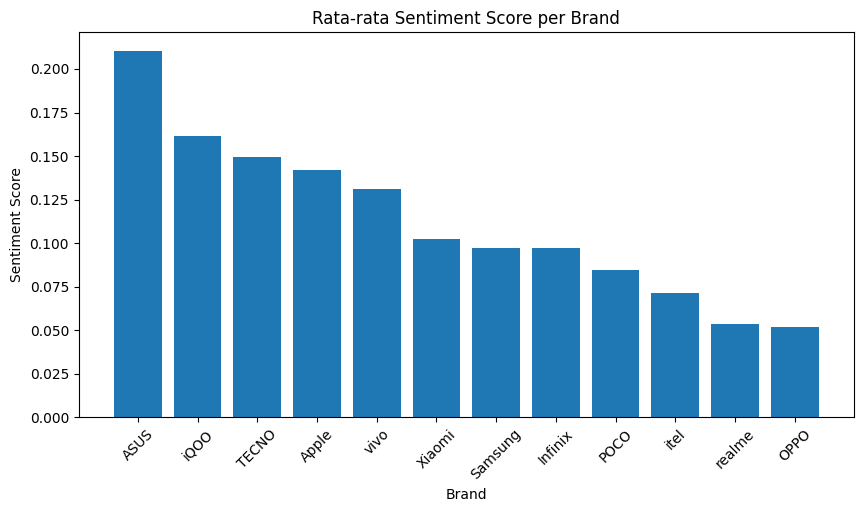

In [147]:
plt.figure(figsize=(10,5))
plt.bar(final_brand_comparison['brand_clean'], final_brand_comparison['sentiment_score_avg'])
plt.title('Rata-rata Sentiment Score per Brand')
plt.xlabel('Brand')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=45)
plt.show()

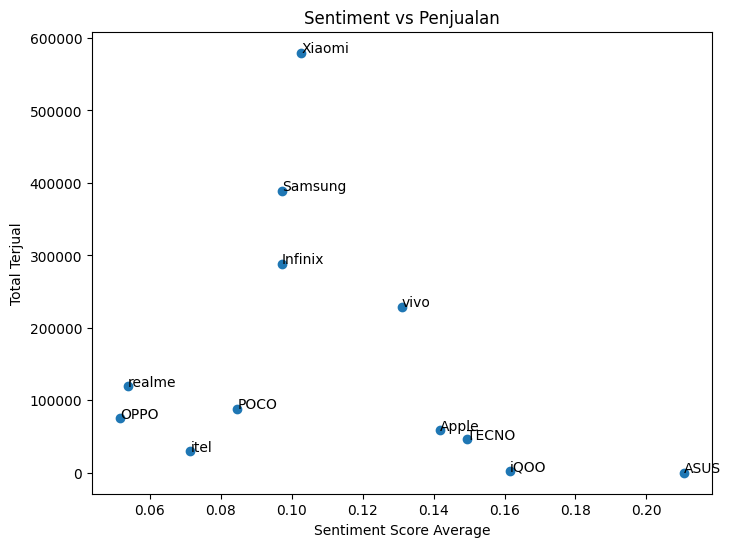

In [148]:
plt.figure(figsize=(8,6))
plt.scatter(final_brand_comparison['sentiment_score_avg'], final_brand_comparison['total_terjual'])

for i, row in final_brand_comparison.iterrows():
    plt.text(row['sentiment_score_avg'], row['total_terjual'], row['brand_clean'])

plt.title('Sentiment vs Penjualan')
plt.xlabel('Sentiment Score Average')
plt.ylabel('Total Terjual')
plt.show()

In [149]:
top3_sales.to_csv('top3_sales.csv', index=False)
bottom3_sales.to_csv('bottom3_sales.csv', index=False)
top3_sentiment.to_csv('top3_sentiment.csv', index=False)
bottom3_sentiment.to_csv('bottom3_sentiment.csv', index=False)

print("File top-bottom berhasil disimpan")

File top-bottom berhasil disimpan


In [150]:
files.download('ecommerce_clean.csv')
files.download('sentiment_clean.csv')
files.download('sentiment_brand_agg.csv')
files.download('ecommerce_brand_agg.csv')
files.download('final_brand_comparison.csv')
files.download('top3_sales.csv')
files.download('bottom3_sales.csv')
files.download('top3_sentiment.csv')
files.download('bottom3_sentiment.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>